In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

import os
os.chdir('/Users/lior/DS6021/DS6021_F26/data')

peng = pd.read_csv("penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)



In [20]:
peng_sex = peng.dropna(subset=["sex"]).reset_index(drop=True)
bike = pd.read_csv("bike-sharing-daily.csv", parse_dates=["dteday"])


In [6]:
f3 = "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm"
full342 = smf.ols(f3, data=peng).fit()
sex333 = smf.ols(f3, data=peng_sex).fit()

print(pd.DataFrame({
    "coef n=342": full342.params,"coef n=333": sex333.params,
    "SE n=342": full342.bse,"SE n=333": sex333.bse,
    "p n=342": full342.pvalues,"p n=333": sex333.pvalues,
}).round(4))

models = [full342, sex333]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "RSE":[np.sqrt(m.scale) for m in models],
    "F":[m.fvalue for m in models],
}, index=["n=342", "n=333"]).round(4))
cols = ["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
missing_sex = peng[peng.sex.isna()]
print(missing_sex.species.value_counts().to_dict())
print("mean of the 9 dropped:\n", missing_sex[cols].mean().round(1))
print("mean of the other 333:\n", peng_sex[cols].mean().round(1))

                   coef n=342  coef n=333  SE n=342  SE n=333  p n=342  \
Intercept          -6424.7647  -6445.4760  561.4693  566.1301   0.0000   
flipper_length_mm     50.2692     50.7621    2.4771    2.4973   0.0000   
bill_depth_mm         20.0495     17.8364   13.6939   13.8259   0.1441   
bill_length_mm         4.1618      3.2929    5.3291    5.3659   0.4354   

                   p n=333  
Intercept           0.0000  
flipper_length_mm   0.0000  
bill_depth_mm       0.1979  
bill_length_mm      0.5399  
           R2  adj_R2       RSE         F
n=342  0.7615  0.7594  393.4048  359.6718
n=333  0.7639  0.7618  393.0046  354.8980
{'Adelie': 5, 'Gentoo': 4}
mean of the 9 dropped:
 flipper_length_mm     199.0
body_mass_g          4005.6
bill_length_mm         41.3
bill_depth_mm          16.6
dtype: float64
mean of the other 333:
 flipper_length_mm     201.0
body_mass_g          4207.1
bill_length_mm         44.0
bill_depth_mm          17.2
dtype: float64


no because the coefficients shift a little bit and the ste are almost the same and r2 increases from 0.761 to 0.764 and rse decreases from 393.4 to 393. so flipper length is the only predictor that actually matters. Losing the penguins just changes the estimations by sampling related noise. 

In [9]:
s0 = smf.ols("body_mass_g ~ flipper_length_mm", data=peng_sex).fit()
s1 = smf.ols("body_mass_g ~ flipper_length_mm + C(sex)", data=peng_sex).fit()
s2 = smf.ols("body_mass_g ~ flipper_length_mm * C(sex)", data=peng_sex).fit()

print(sm.stats.anova_lm(s0, s1, s2))

models = [s0, s1, s2]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "AIC":[m.aic for m in models],
    "BIC":[m.bic for m in models],
}, index=["flipper only", "+ sex (additive)", "flipper * sex"]).round(4))

print(s1.summary().tables[1])
print(s2.summary().tables[1])

print(peng_sex.groupby("sex")[["body_mass_g", "flipper_length_mm"]].mean().round(1))
print("female slope:", round(s2.params["flipper_length_mm"], 2))
print("male slope:  ", round(s2.params["flipper_length_mm"] + s2.params["flipper_length_mm:C(sex)[T.male]"], 2))

   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     331.0  5.121196e+07      0.0           NaN        NaN           NaN
1     330.0  4.179537e+07      1.0  9.416589e+06  74.126700  3.050629e-16
2     329.0  4.179409e+07      1.0  1.286001e+03   0.010123  9.199177e-01
                      R2  adj_R2        AIC        BIC
flipper only      0.7621  0.7614  4926.1457  4933.7620
+ sex (additive)  0.8058  0.8047  4860.4843  4871.9087
flipper * sex     0.8058  0.8041  4862.4740  4877.7066
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.798    -18.931      0.000   -5972.515   -4848.085
C(sex)[T.male]      347.8503     40.342      8.623      0.000     268.491     427.209
flipper_length_mm    46.9822      1.441     32.598      0.000      44.147      49.817
                                       coef    std err

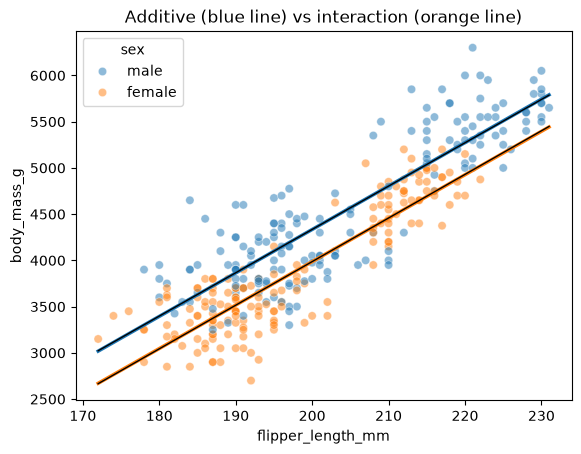

In [11]:
colors = {"female": "tab:orange", "male": "tab:blue"}
grid = np.linspace(peng_sex.flipper_length_mm.min(), peng_sex.flipper_length_mm.max(), 50)

sns.scatterplot(data=peng_sex, x="flipper_length_mm", y="body_mass_g", hue="sex", palette=colors, alpha=0.5)
for sex in ["female", "male"]:
    new_data = pd.DataFrame({"flipper_length_mm": grid, "sex": sex})
    plt.plot(grid, s1.predict(new_data), color=colors[sex], lw=2.5)   
    plt.plot(grid, s2.predict(new_data), color="black",lw=1) 
plt.title("Additive (blue line) vs interaction (orange line)")
plt.show()

a. the additive model because adding the sex helps the adj r2 increase from 0.761 to 0.805 but the interaction models adj r2 is slignly lower an the AIC and BIC are bith higher, so it doesnt help.

b. the males weiegh 348 grams heavier at the same flipper length and the flipper length adds 47 grams per mm for males and females. theres a gap between the sexes by about 683 grams half of it is from males having long flipper lengths

c. The scatterplot shows two clear lines and with males averaging higher than females at any length and are completely parallel which shows us that the sex should be in the model as a vertical shift.

In [ ]:
#q3
t1 = smf.ols("body_mass_g ~ C(sex) + C(species)", data=peng_sex).fit()
t2 = smf.ols("body_mass_g ~ C(sex) * C(species)", data=peng_sex).fit()

print(sm.stats.anova_lm(t1, t2))
models = [t1, t2]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "AIC":[m.aic for m in models],
    "BIC":[m.bic for m in models],
}, index=["additive", "interaction"]).round(4))

print(t1.summary().tables[1])
print(t2.summary().tables[1])
means = peng_sex.groupby(["species", "sex"]).body_mass_g.mean().unstack()
means["gap"] = means["male"] - means["female"]
print(means.round(1))

   df_resid           ssr  df_diff       ss_diff         F    Pr(>F)
0     329.0  3.297919e+07      0.0           NaN       NaN       NaN
1     327.0  3.130263e+07      2.0  1.676557e+06  8.756997  0.000197
                 R2  adj_R2        AIC        BIC
additive     0.8468  0.8454  4783.5935  4798.8261
interaction  0.8546  0.8524  4770.2194  4793.0683
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3372.3868     31.427    107.308      0.000    3310.563    3434.210
C(sex)[T.male]            667.5552     34.704     19.236      0.000     599.285     735.825
C(species)[T.Chinstrap]    26.9239     46.483      0.579      0.563     -64.518     118.366
C(species)[T.Gentoo]     1377.8580     39.104     35.236      0.000    1300.932    1454.784
                                             coef    std err          t      P>|t|      [0.

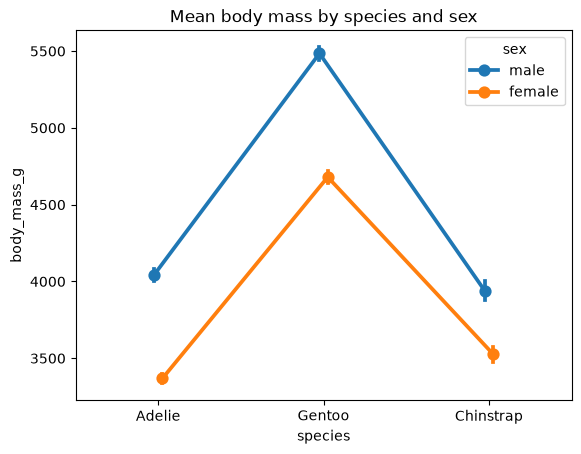

In [15]:
sns.pointplot(data=peng_sex, x="species", y="body_mass_g", hue="sex", palette=colors, errorbar="se", dodge=True)
plt.title("Mean body mass by species and sex")
plt.show()

a. the interaction model because adj r2 increases from 0.842 to 0.852 and AIC and BIC both decrease.

b. id interpret the coeficcients of the interaction model and the actual effect only is specific to the reference group of the other variable. the sex difference is about 675g in adelie, 412g in chinstrap and 805g in gentoo and the additive model had the same gap rsult of about 668g and that averages the differences.

c. the point plot shows the mean masss by species and also bysex in two separate lines and the vertical gap between the lines is the gender effect and it changes depending on the species. 

In [ ]:
#q4 a
cas_a = smf.ols("casual ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
cas_i = smf.ols("casual ~ temp * C(workingday) + hum + windspeed", data=bike).fit()

print(sm.stats.anova_lm(cas_a, cas_i))

models = [cas_a, cas_i]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "AIC":[m.aic for m in models],
    "BIC":[m.bic for m in models],
}, index=["additive", "interaction"]).round(4))

print(cas_a.summary().tables[1])
print(cas_i.summary().tables[1])

   df_resid           ssr  df_diff       ss_diff           F        Pr(>F)
0     726.0  1.276423e+08      0.0           NaN         NaN           NaN
1     725.0  1.103186e+08      1.0  1.732378e+07  113.849712  8.681452e-25
                 R2  adj_R2         AIC         BIC
additive     0.6291  0.6271  10907.8988  10930.8709
interaction  0.6795  0.6772  10803.2752  10830.8417
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1063.5527    101.370     10.492      0.000     864.540    1262.566
C(workingday)[T.1]  -806.6343     33.410    -24.143      0.000    -872.226    -741.042
temp                2149.5173     86.324     24.901      0.000    1980.043    2318.991
hum                 -812.7411    112.979     -7.194      0.000   -1034.545    -590.937
windspeed          -1145.3093    208.554     -5.492      0.000   -1554.750    -735.869
          

In [17]:
#q4 b

reg_a = smf.ols("registered ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
reg_i = smf.ols("registered ~ temp * C(workingday) + hum + windspeed", data=bike).fit()

print(sm.stats.anova_lm(reg_a, reg_i))

models = [reg_a, reg_i]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "AIC":[m.aic for m in models],
    "BIC":[m.bic for m in models],
}, index=["additive", "interaction"]).round(4))

print(reg_a.summary().tables[1])
print(reg_i.summary().tables[1])

   df_resid           ssr  df_diff       ss_diff         F   Pr(>F)
0     726.0  1.020706e+09      0.0           NaN       NaN      NaN
1     725.0  1.016851e+09      1.0  3.855347e+06  2.748806  0.09776
                 R2  adj_R2         AIC         BIC
additive     0.4256  0.4225  12427.6610  12450.6331
interaction  0.4278  0.4239  12426.8947  12454.4612
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2945.8161    286.657     10.276      0.000    2383.041    3508.591
C(workingday)[T.1]   932.4392     94.478      9.869      0.000     746.956    1117.922
temp                4460.1902    244.109     18.271      0.000    3980.947    4939.434
hum                -2294.0896    319.485     -7.181      0.000   -2921.314   -1666.866
windspeed          -3656.3914    589.755     -6.200      0.000   -4814.220   -2498.563
                              c

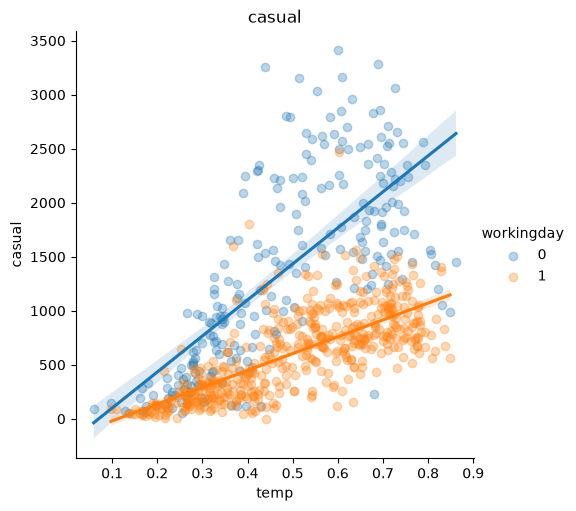

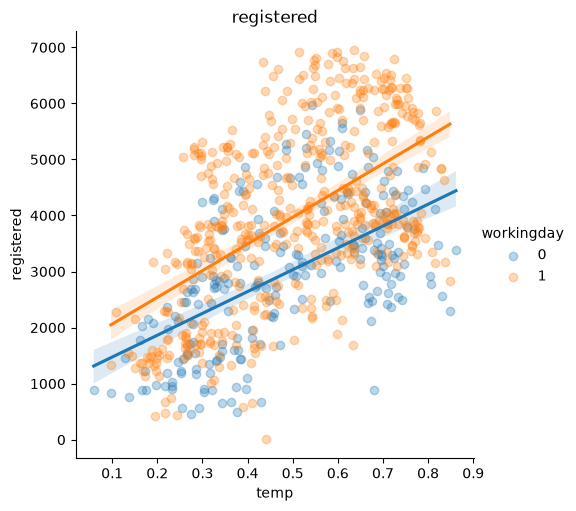

In [22]:
sns.lmplot(data=bike, x="temp", y="casual", hue="workingday", scatter_kws={"alpha": 0.3})
plt.title("casual")
sns.lmplot(data=bike, x="temp", y="registered", hue="workingday", scatter_kws={"alpha": 0.3})
plt.title("registered")
plt.show()

In [21]:
cnt_a = smf.ols("cnt ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
cnt_i = smf.ols("cnt ~ temp * C(workingday) + hum + windspeed", data=bike).fit()
print(pd.DataFrame({
    "casual": cas_i.params,
    "registered": reg_i.params,
    "sum": cas_i.params + reg_i.params,
    "cnt model": cnt_i.params,
}).round(1))

print("cnt interaction p-value:", round(cnt_i.pvalues["temp:C(workingday)[T.1]"], 3))
print("cnt working-day coef (additive):", round(cnt_a.params["C(workingday)[T.1]"], 1))
print("casual + registered working-day coefs:",
      round(cas_a.params["C(workingday)[T.1]"], 1), "+", round(reg_a.params["C(workingday)[T.1]"], 1))
print("share of rentals that are registered:", round(bike.registered.sum() / bike.cnt.sum(), 3))

                         casual  registered     sum  cnt model
Intercept                 492.6      3215.2  3707.7     3707.7
C(workingday)[T.1]         68.4       519.6   588.1      588.1
temp                     3354.7      3891.6  7246.4     7246.4
temp:C(workingday)[T.1] -1792.4       845.6  -946.9     -946.9
hum                      -840.4     -2281.0 -3121.5    -3121.5
windspeed               -1102.4     -3676.6 -4779.0    -4779.0
cnt interaction p-value: 0.123
cnt working-day coef (additive): 125.8
casual + registered working-day coefs: -806.6 + 932.4
share of rentals that are registered: 0.812


the casual outcome had an f test of 113.8 and the registered had an f test of 2.75 with a p of 0.098. the r2 increased in the casual outcome from 0.629 to 0.679 and the registered from 0.4256 to 0.4278. the AIC decreased for casual and decreased a tiny bit for refgisterd. the better model for casual is an interaction model and the better model for registered is additive model

c. casual rders are a lot more common on non worjung days abd in the additive model the working days are -807 casual renters. they are out on weejends and holidays, so temperature matters a lot when people want to ride their bikes for leisure. registered riders have a working days of 932 registered retals in the additive model and basically the opposite of casua, and temperature affects those riders about the same, but weather sways them a lot less since they are most likely commuters.  

d. Because theyre not predictors. putting casual and registered in the model for cnt might cause data leakage since cnt is made up of both of those. splitting them helps in seeing the exact data for each because combining them averages them and hides both of them.